# Resource Allocation Evaluation — Single Strategy

This notebook evaluates resource allocation strategies using event logs produced by the discrete event simulation engine.


## 1 — Global Configuration

In [34]:
# ── ONLY USER-CONFIGURABLE CELL ────────────────────────────────────────────────
COST_PER_FTE_HOUR = 50.0   # € (or $) per occupied resource-hour
# ───────────────────────────────────────────────────────────────────────────────

## 2 — Imports & Path Setup

In [35]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pm4py

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)

# ── Resolve log path relative to this notebook ────────────────────────────────
NOTEBOOK_DIR = Path(os.path.abspath(""))          # works in both Jupyter & VS Code
LOG_PATH = (
    NOTEBOOK_DIR.parents[0]                        
    / "integration"
    / "output"
    / "simulated_log.xes"
)
assert LOG_PATH.exists(), f"Log not found: {LOG_PATH}"
print(f"Log path : {LOG_PATH}")
print(f"pm4py    : {pm4py.__version__}")

Log path : /Users/lgk/git/uni/BPSO25/process-simulation-engine/integration/output/simulated_log.xes
pm4py    : 2.7.19.5


## 3 — Data Loading & Preprocessing

In [36]:
REQUIRED_COLS = {"case:concept:name", "concept:name", "time:timestamp"}
OPTIONAL_COLS = {"org:resource", "lifecycle:transition"}


def load_log(path: Path) -> pd.DataFrame:
    """Load a XES file and return a flat DataFrame with standardised column names."""
    log = pm4py.read_xes(str(path))
    df = pm4py.convert_to_dataframe(log)

    # Normalise column names to lowercase for robustness
    df.columns = [c.lower() for c in df.columns]
    rename_map = {
        "case:concept:name": "case:concept:name",
        "concept:name": "concept:name",
        "time:timestamp": "time:timestamp",
        "org:resource": "org:resource",
        "lifecycle:transition": "lifecycle:transition",
    }
    df = df.rename(columns={c.lower(): c for c in rename_map})

    # Validate required columns
    missing = REQUIRED_COLS - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # Ensure timestamps are timezone-aware pandas Timestamps
    df["time:timestamp"] = pd.to_datetime(df["time:timestamp"], utc=True)

    return df


def validate_and_describe(df: pd.DataFrame) -> None:
    """Print a brief structural summary of the loaded log."""
    has_resource   = "org:resource"           in df.columns
    has_lifecycle  = "lifecycle:transition"   in df.columns
    n_cases        = df["case:concept:name"].nunique()
    n_events       = len(df)
    activities     = sorted(df["concept:name"].unique())
    date_range     = (df["time:timestamp"].min(), df["time:timestamp"].max())

    print(f"Events       : {n_events:,}")
    print(f"Cases        : {n_cases:,}")
    print(f"Activities   : {len(activities)}")
    print(f"Date range   : {date_range[0].date()} → {date_range[1].date()}")
    print(f"Resource col : {'✓' if has_resource else '✗  (resource metrics will be skipped)'}")
    print(f"Lifecycle col: {'✓' if has_lifecycle else '✗  (FTE metrics cannot be computed)'}")
    if has_lifecycle:
        vals = df["lifecycle:transition"].str.lower().unique()
        print(f"  Transitions: {sorted(vals)}")


df_raw = load_log(LOG_PATH)
validate_and_describe(df_raw)

parsing log, completed traces :: 100%|██████████| 30000/30000 [00:19<00:00, 1526.83it/s]


Events       : 573,956
Cases        : 30,000
Activities   : 24
Date range   : 2016-01-01 → 2016-11-21
Resource col : ✓
Lifecycle col: ✓
  Transitions: ['complete', 'start']


## 4 — Duration Extraction (start → complete pairing)

In [37]:
def extract_activity_durations(df: pd.DataFrame) -> tuple[pd.DataFrame, bool]:
    """
    Pair start and complete lifecycle events to compute real activity durations.

    Returns
    -------
    df_durations : DataFrame with columns
        [case:concept:name, concept:name, org:resource, start_time, complete_time, duration_hours]
    has_durations : bool — True if start/complete pairing was possible
    """
    has_lifecycle = "lifecycle:transition" in df.columns

    if has_lifecycle:
        lc = df["lifecycle:transition"].str.lower()
        starts    = df[lc == "start"].copy()
        completes = df[lc == "complete"].copy()

        if starts.empty or completes.empty:
            print("⚠  Lifecycle column present but no start/complete pairs found. "
                  "FTE metrics will not be computed.")
            has_durations = False
        else:
            starts    = starts.rename(columns={"time:timestamp": "start_time"})
            completes = completes.rename(columns={"time:timestamp": "complete_time"})

            merge_cols = ["case:concept:name", "concept:name"]
            if "org:resource" in df.columns:
                merge_cols.append("org:resource")

            df_dur = pd.merge(
                starts[merge_cols + ["start_time"]],
                completes[merge_cols + ["complete_time"]],
                on=merge_cols,
                how="inner",
            )
            df_dur["duration_hours"] = (
                (df_dur["complete_time"] - df_dur["start_time"])
                .dt.total_seconds() / 3600
            )
            # Drop negative / zero durations (data artefacts)
            df_dur = df_dur[df_dur["duration_hours"] > 0].reset_index(drop=True)

            print(f"Activity instances with durations : {len(df_dur):,}")
            print(f"Duration range (h)                : "
                  f"{df_dur['duration_hours'].min():.4f} – {df_dur['duration_hours'].max():.4f}")
            has_durations = True
    else:
        print("ℹ  No lifecycle:transition column found. "
              "Cycle-time metrics will be computed from first/last event per case. "
              "FTE metrics cannot be computed.")
        df_dur = pd.DataFrame()
        has_durations = False

    return df_dur, has_durations


df_durations, HAS_DURATIONS = extract_activity_durations(df_raw)

Activity instances with durations : 75,862
Duration range (h)                : 1.0000 – 112.7333


## 5 — Case-Level Metrics

In [38]:
def compute_case_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute per-case metrics derived from first and last observed event.

    Returns a DataFrame indexed by case ID with:
        case_start, case_end, cycle_time_days, n_events, handovers
    """
    grp = df.sort_values("time:timestamp").groupby("case:concept:name")

    case_start  = grp["time:timestamp"].min().rename("case_start")
    case_end    = grp["time:timestamp"].max().rename("case_end")
    n_events    = grp.size().rename("n_events")

    df_cases = pd.concat([case_start, case_end, n_events], axis=1)
    df_cases["cycle_time_days"] = (
        (df_cases["case_end"] - df_cases["case_start"]).dt.total_seconds() / 86_400
    )

    # Handovers: count distinct consecutive-resource switches within each case
    if "org:resource" in df.columns:
        def count_handovers(sub: pd.DataFrame) -> int:
            resources = (
                sub.sort_values("time:timestamp")["org:resource"]
                .dropna()
                .tolist()
            )
            return sum(1 for a, b in zip(resources, resources[1:]) if a != b)

        df_cases["handovers"] = grp.apply(count_handovers)
    else:
        df_cases["handovers"] = np.nan

    return df_cases.reset_index()


df_cases = compute_case_metrics(df_raw)

print(df_cases[["cycle_time_days", "n_events", "handovers"]].describe().round(4))

       cycle_time_days   n_events  handovers
count       30000.0000 30000.0000 30000.0000
mean            1.1076    19.1319     9.4023
std             0.6513     8.0312     4.7614
min             0.2083     6.0000     0.0000
25%             0.7083    14.0000     6.0000
50%             0.9719    17.0000     9.0000
75%             1.3326    23.0000    12.0000
max             8.9708   262.0000   105.0000


## 6 — Resource-Level Metrics

In [39]:
def compute_resource_metrics(
    df_durations: pd.DataFrame,
    has_durations: bool,
) -> pd.DataFrame | None:
    """
    Compute per-resource occupied hours and work-share.

    Returns None when no durations are available (no lifecycle data).
    Columns: resource, busy_hours, work_share
    """
    if not has_durations or "org:resource" not in df_durations.columns:
        print("ℹ  Resource-level metrics require start/complete lifecycle pairs.")
        return None

    df_res = (
        df_durations.groupby("org:resource")["duration_hours"]
        .sum()
        .reset_index()
        .rename(columns={"org:resource": "resource", "duration_hours": "busy_hours"})
        .sort_values("busy_hours", ascending=False)
        .reset_index(drop=True)
    )

    total_busy = df_res["busy_hours"].sum()
    df_res["work_share"] = df_res["busy_hours"] / total_busy   # fraction [0,1]

    print(df_res.to_string(index=False))
    return df_res


df_resources = compute_resource_metrics(df_durations, HAS_DURATIONS)

resource  busy_hours  work_share
  User_1  73763.3333      0.5406
User_120   1171.8167      0.0086
User_125   1153.4167      0.0085
 User_41    838.2167      0.0061
User_122    818.4833      0.0060
 User_18    816.9333      0.0060
 User_23    814.2667      0.0060
 User_50    799.4000      0.0059
 User_46    797.9333      0.0058
 User_42    774.0000      0.0057
 User_57    772.5833      0.0057
 User_51    770.7667      0.0056
 User_31    764.8167      0.0056
 User_11    743.9667      0.0055
 User_15    734.6500      0.0054
 User_17    722.0000      0.0053
 User_61    712.0000      0.0052
 User_40    710.3833      0.0052
 User_47    709.0000      0.0052
 User_43    696.5167      0.0051
 User_39    694.0000      0.0051
 User_25    692.0000      0.0051
 User_24    686.1167      0.0050
User_103    664.0000      0.0049
 User_53    660.0000      0.0048
 User_58    657.0000      0.0048
 User_35    656.0000      0.0048
 User_32    654.5333      0.0048
 User_54    654.0667      0.0048
 User_49  

## 7 — All Metrics: Basic + Additional

In [40]:
# ── Basic metrics ─────────────────────────────────────────────────────────────

def metric_avg_cycle_time(df_cases: pd.DataFrame) -> float:
    """Mean case duration (days) from first to last event."""
    return float(df_cases["cycle_time_days"].mean())


def metric_median_cycle_time(df_cases: pd.DataFrame) -> float:
    """Median case duration (days)."""
    return float(df_cases["cycle_time_days"].median())


def metric_range_cycle_time(df_cases: pd.DataFrame) -> float:
    """Range of cycle times: max − min (days)."""
    return float(df_cases["cycle_time_days"].max() - df_cases["cycle_time_days"].min())


def metric_throughput(df_cases: pd.DataFrame) -> float:
    """
    Completed cases per calendar day.

    Uses the total calendar span of the log (case_start.min → case_end.max).
    """
    span_days = (
        df_cases["case_end"].max() - df_cases["case_start"].min()
    ).total_seconds() / 86_400
    return float(len(df_cases) / span_days) if span_days > 0 else np.nan


def metric_avg_resource_occupation(df_resources: pd.DataFrame | None) -> float:
    """
    Mean work share across resources.

    Each resource's work share = its busy hours / total busy hours.
    The mean of these shares equals 1/n_resources by definition, but the
    interpretation is meaningful when compared across strategies.
    """
    if df_resources is None:
        return np.nan
    return float(df_resources["work_share"].mean())


def metric_weighted_resource_fairness(df_resources: pd.DataFrame | None) -> float:
    """
    Weighted deviation of resource work shares from the mean share.

    Formula:
        WRF = Σ_i  (busy_i / total_busy) * |share_i − mean_share|

    A value close to 0 indicates a balanced allocation.
    A higher value indicates concentration of work on fewer resources.
    """
    if df_resources is None or len(df_resources) == 0:
        return np.nan
    shares     = df_resources["work_share"].values
    mean_share = shares.mean()
    weights    = df_resources["busy_hours"].values / df_resources["busy_hours"].sum()
    return float(np.sum(weights * np.abs(shares - mean_share)))


# ── Additional metrics ────────────────────────────────────────────────────────

def metric_total_busy_hours(df_resources: pd.DataFrame | None) -> float:
    """Total resource-occupied hours across all resources."""
    if df_resources is None:
        return np.nan
    return float(df_resources["busy_hours"].sum())


def metric_total_fte_cost(total_busy_hours: float, cost_per_fte_hour: float) -> float:
    """Total FTE cost = total busy hours × COST_PER_FTE_HOUR."""
    return float(total_busy_hours * cost_per_fte_hour)


def metric_cost_per_case(total_fte_cost: float, n_cases: int) -> float:
    """FTE cost per completed case."""
    return float(total_fte_cost / n_cases) if n_cases > 0 else np.nan


def metric_avg_handovers_per_case(df_cases: pd.DataFrame) -> float:
    """Mean number of resource switches per case."""
    if "handovers" not in df_cases.columns or df_cases["handovers"].isna().all():
        return np.nan
    return float(df_cases["handovers"].mean())


# ── Assemble all metrics ───────────────────────────────────────────────────────
total_busy   = metric_total_busy_hours(df_resources)
fte_cost     = metric_total_fte_cost(total_busy, COST_PER_FTE_HOUR)
n_completed  = len(df_cases)

metrics = {
    # Basic (required)
    "Avg Cycle Time (days)"             : metric_avg_cycle_time(df_cases),
    "Avg Resource Occupation (share)"   : metric_avg_resource_occupation(df_resources),
    "Weighted Resource Fairness"        : metric_weighted_resource_fairness(df_resources),
    # Additional
    "Median Cycle Time (days)"          : metric_median_cycle_time(df_cases),
    "Range Cycle Time (days)"           : metric_range_cycle_time(df_cases),
    "Throughput (cases/day)"            : metric_throughput(df_cases),
    "Total Busy Hours"                  : total_busy,
    "Total FTE Cost (€)"                : fte_cost,
    "Cost per Completed Case (€)"       : metric_cost_per_case(fte_cost, n_completed),
    "Avg Handovers per Case"            : metric_avg_handovers_per_case(df_cases),
}

for k, v in metrics.items():
    print(f"  {k:<40} {v:.4f}" if not np.isnan(v) else f"  {k:<40} n/a")

  Avg Cycle Time (days)                    1.1076
  Avg Resource Occupation (share)          0.0074
  Weighted Resource Fairness               0.2897
  Median Cycle Time (days)                 0.9719
  Range Cycle Time (days)                  8.7625
  Throughput (cases/day)                   92.2830
  Total Busy Hours                         136459.1333
  Total FTE Cost (€)                       6822956.6667
  Cost per Completed Case (€)              227.4319
  Avg Handovers per Case                   9.4023


## 8 — Summary Table (single-row overview)

In [41]:
summary = pd.DataFrame([metrics]).rename(index={0: "OrdinoR FullRecall"})
summary.index.name = "Strategy"
summary.T  # transpose for readability

Strategy,OrdinoR FullRecall
Avg Cycle Time (days),1.1076
Avg Resource Occupation (share),0.0074
Weighted Resource Fairness,0.2897
Median Cycle Time (days),0.9719
Range Cycle Time (days),8.7625
Throughput (cases/day),92.2830
Total Busy Hours,136459.1333
Total FTE Cost (€),6822956.6667
Cost per Completed Case (€),227.4319
Avg Handovers per Case,9.4023


## 9 — Advanced Metric: Workload Gini Coefficient

### Justification

The **Gini coefficient** measures how unevenly busy hours are distributed across resources. Unlike the weighted fairness metric (which measures deviation from the mean), the Gini captures the *cumulative concentration* of work — a standard indicator from economics adapted here to detect whether a small subset of resources carries a disproportionate share of the load.

| Value | Interpretation |
|---|---|
| 0.0 | Perfect equality — every resource has identical busy hours |
| 0.0 – 0.3 | Low concentration — workload is broadly distributed |
| 0.3 – 0.6 | Moderate concentration — some resources dominate |
| > 0.6 | High concentration — bottleneck risk; potential burnout |

**Why it matters for resource allocation:**  
A high Gini exposes bottleneck resources that could become queue-chokepoints under load increases. It also flags under-utilised resources that could absorb more work in a rebalanced strategy. When comparing multiple allocation strategies, the Gini provides a single, scale-invariant number.

Workload Gini Coefficient : 0.6577
Interpretation            : High concentration — bottleneck risk


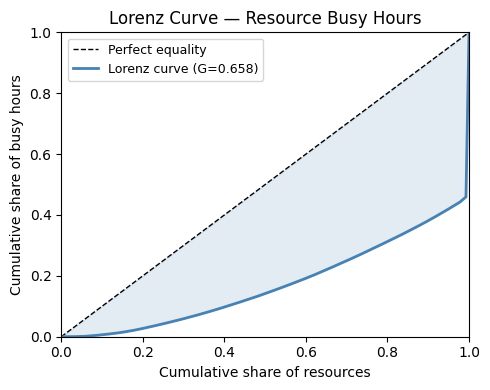

In [42]:
def gini_coefficient(values: np.ndarray) -> float:
    """
    Compute the Gini coefficient for a non-negative array.

    Formula (sorted-array formulation, O(n log n)):
        G = (2 * Σ_i  i * x_i) / (n * Σ x_i)  − (n+1)/n
    where x_i are sorted ascending values and i is 1-based rank.
    """
    v = np.sort(np.asarray(values, dtype=float))
    v = v[v >= 0]          # drop negatives (artefacts)
    n = len(v)
    if n == 0 or v.sum() == 0:
        return np.nan
    ranks = np.arange(1, n + 1)
    return float((2 * (ranks * v).sum()) / (n * v.sum()) - (n + 1) / n)


def interpret_gini(g: float) -> str:
    if np.isnan(g):
        return "n/a"
    if g < 0.3:
        return "Low concentration (broadly distributed)"
    if g < 0.6:
        return "Moderate concentration"
    return "High concentration — bottleneck risk"


if df_resources is not None:
    gini = gini_coefficient(df_resources["busy_hours"].values)
    print(f"Workload Gini Coefficient : {gini:.4f}")
    print(f"Interpretation            : {interpret_gini(gini)}")

    # Lorenz curve
    sorted_hours = np.sort(df_resources["busy_hours"].values)
    cum_share    = np.cumsum(sorted_hours) / sorted_hours.sum()
    cum_pop      = np.arange(1, len(sorted_hours) + 1) / len(sorted_hours)

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect equality")
    ax.plot(np.concatenate([[0], cum_pop]),
            np.concatenate([[0], cum_share]),
            color="steelblue", lw=2, label=f"Lorenz curve (G={gini:.3f})")
    ax.fill_between(
        np.concatenate([[0], cum_pop]),
        np.concatenate([[0], cum_pop]),
        np.concatenate([[0], cum_share]),
        alpha=0.15, color="steelblue",
    )
    ax.set_xlabel("Cumulative share of resources")
    ax.set_ylabel("Cumulative share of busy hours")
    ax.set_title("Lorenz Curve — Resource Busy Hours")
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()
else:
    print("ℹ  Gini coefficient requires start/complete lifecycle data.")

## 10 — Visualisations

### 10.1 — Cycle Time Distribution

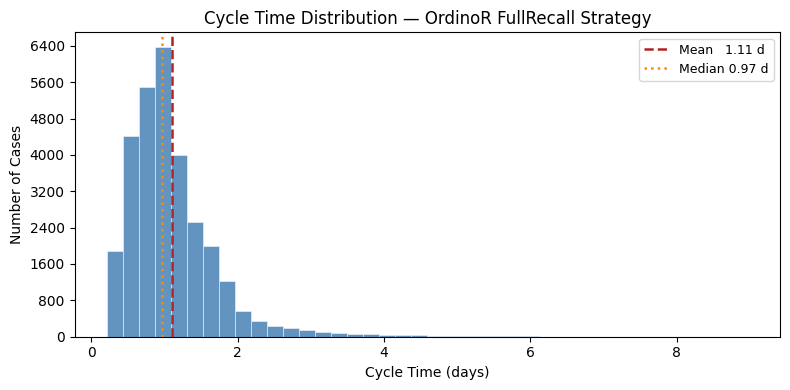

In [43]:
ct = df_cases["cycle_time_days"].dropna()
avg_ct    = ct.mean()
median_ct = ct.median()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ct, bins=40, color="steelblue", edgecolor="white", linewidth=0.4, alpha=0.85)
ax.axvline(avg_ct,    color="firebrick",   lw=1.8, ls="--", label=f"Mean   {avg_ct:.2f} d")
ax.axvline(median_ct, color="darkorange",  lw=1.8, ls=":",  label=f"Median {median_ct:.2f} d")
ax.set_xlabel("Cycle Time (days)")
ax.set_ylabel("Number of Cases")
ax.set_title("Cycle Time Distribution — OrdinoR FullRecall Strategy")
ax.legend(fontsize=9)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

### 10.2 — Busy Hours per Resource

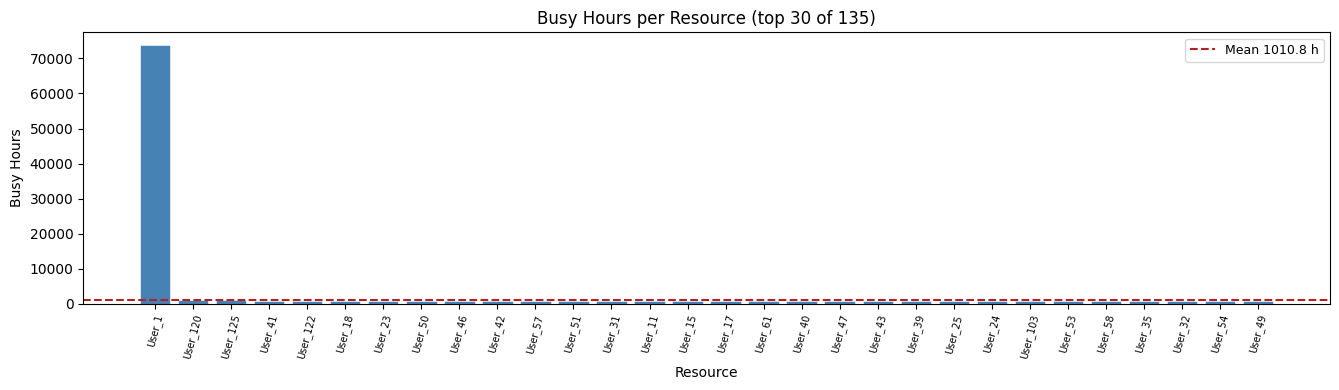

In [44]:
if df_resources is not None:
    MAX_SHOW = 30   # cap for readability when many resources exist
    df_plot  = df_resources.head(MAX_SHOW)
    avg_line = df_resources["busy_hours"].mean()

    fig, ax = plt.subplots(figsize=(max(8, len(df_plot) * 0.45), 4))
    bars = ax.bar(
        df_plot["resource"], df_plot["busy_hours"],
        color="steelblue", edgecolor="white", linewidth=0.4
    )
    ax.axhline(avg_line, color="firebrick", lw=1.5, ls="--",
               label=f"Mean {avg_line:.1f} h")
    ax.set_xlabel("Resource")
    ax.set_ylabel("Busy Hours")
    ax.set_title(
        f"Busy Hours per Resource (top {len(df_plot)} of {len(df_resources)})"
        if len(df_resources) > MAX_SHOW else "Busy Hours per Resource"
    )
    ax.legend(fontsize=9)
    ax.tick_params(axis="x", rotation=75, labelsize=7)
    plt.tight_layout()
    plt.show()
else:
    print("ℹ  Busy-hours plot requires start/complete lifecycle data.")

### 10.3 — Handovers per Case Distribution

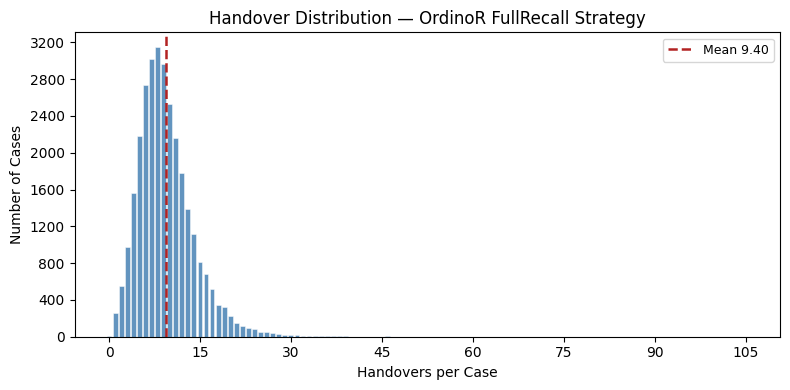

In [45]:
if "handovers" in df_cases.columns and not df_cases["handovers"].isna().all():
    ho = df_cases["handovers"].dropna().astype(int)
    avg_ho = ho.mean()

    fig, ax = plt.subplots(figsize=(8, 4))
    counts  = ho.value_counts().sort_index()
    ax.bar(counts.index, counts.values,
           color="steelblue", edgecolor="white", linewidth=0.4, alpha=0.85)
    ax.axvline(avg_ho, color="firebrick", lw=1.8, ls="--",
               label=f"Mean {avg_ho:.2f}")
    ax.set_xlabel("Handovers per Case")
    ax.set_ylabel("Number of Cases")
    ax.set_title("Handover Distribution — OrdinoR FullRecall Strategy")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("ℹ  Handover plot requires an org:resource column.")

## 11 — Employee Termination Score

### Step 1 — Compute Per-Resource Features

In [46]:
def compute_resource_features(
    df_raw: pd.DataFrame,
    df_durations: pd.DataFrame,
    df_cases: pd.DataFrame,
    has_durations: bool,
    cost_per_fte_hour: float,
) -> pd.DataFrame:
    """
    Build a per-resource feature table for the termination score.

    Requires org:resource and start/complete lifecycle pairs.
    Returns None-filled numeric columns when data is insufficient.
    """
    if "org:resource" not in df_raw.columns:
        raise ValueError("org:resource column is required for the termination score.")
    if not has_durations:
        raise ValueError(
            "start/complete lifecycle pairs are required for the termination score. "
            "FTE-based features cannot be computed from timestamp-only logs."
        )

    # ── busy_hours & fte_cost ────────────────────────────────────────────────
    busy = (
        df_durations.groupby("org:resource")["duration_hours"]
        .sum()
        .reset_index()
        .rename(columns={"org:resource": "resource", "duration_hours": "busy_hours"})
    )
    busy["fte_cost"] = busy["busy_hours"] * cost_per_fte_hour
    total_busy = busy["busy_hours"].sum()
    busy["workload_share"] = busy["busy_hours"] / total_busy

    # ── event & case counts ──────────────────────────────────────────────────
    # Use complete events only (one row per executed activity instance)
    df_complete = df_raw.copy()
    if "lifecycle:transition" in df_raw.columns:
        df_complete = df_raw[df_raw["lifecycle:transition"].str.lower() == "complete"].copy()

    event_counts = (
        df_complete.groupby("org:resource")
        .size()
        .reset_index(name="completed_events_count")
        .rename(columns={"org:resource": "resource"})
    )
    case_counts = (
        df_complete.groupby("org:resource")["case:concept:name"]
        .nunique()
        .reset_index()
        .rename(columns={"org:resource": "resource", "case:concept:name": "distinct_cases_count"})
    )

    # ── avg cycle time of cases each resource touched ───────────────────────
    case_ct = df_cases[["case:concept:name", "cycle_time_days"]].copy()
    resource_cases = (
        df_complete[["org:resource", "case:concept:name"]]
        .drop_duplicates()
        .rename(columns={"org:resource": "resource"})
    )
    resource_ct = (
        resource_cases.merge(case_ct, on="case:concept:name", how="left")
        .groupby("resource")["cycle_time_days"]
        .mean()
        .reset_index()
        .rename(columns={"cycle_time_days": "avg_cycle_time_of_cases_involved"})
    )

    global_avg_ct = df_cases["cycle_time_days"].mean()

    # ── assemble ─────────────────────────────────────────────────────────────
    rm = (
        busy
        .merge(event_counts, on="resource", how="left")
        .merge(case_counts,  on="resource", how="left")
        .merge(resource_ct,  on="resource", how="left")
    )

    rm["productivity"]             = rm["completed_events_count"] / rm["busy_hours"]
    rm["contribution_per_cost"]    = rm["distinct_cases_count"]   / rm["fte_cost"]
    rm["global_avg_cycle_time"]    = global_avg_ct
    rm["cycle_time_delta"]         = rm["avg_cycle_time_of_cases_involved"] - global_avg_ct

    col_order = [
        "resource", "busy_hours", "fte_cost",
        "completed_events_count", "distinct_cases_count",
        "productivity", "workload_share", "contribution_per_cost",
        "avg_cycle_time_of_cases_involved", "global_avg_cycle_time", "cycle_time_delta",
    ]
    return rm[col_order].reset_index(drop=True)


resource_metrics = compute_resource_features(
    df_raw, df_durations, df_cases, HAS_DURATIONS, COST_PER_FTE_HOUR
)
print(f"Resources evaluated: {len(resource_metrics)}")
resource_metrics.head(10)

Resources evaluated: 135


,resource,busy_hours,fte_cost,completed_events_count,distinct_cases_count,productivity,workload_share,contribution_per_cost,avg_cycle_time_of_cases_involved,global_avg_cycle_time,cycle_time_delta
0,User_1,73763.3333,3688166.6667,74848,26880,1.0147,0.5406,0.0073,1.1294,1.1076,0.0217
1,User_10,649.0000,32450.0000,5098,2970,7.8552,0.0048,0.0915,1.3197,1.1076,0.2121
2,User_100,494.0000,24700.0000,4069,2415,8.2368,0.0036,0.0978,1.2164,1.1076,0.1088
3,User_101,504.0333,25201.6667,3173,1693,6.2952,0.0037,0.0672,1.2833,1.1076,0.1756
4,User_102,397.0000,19850.0000,2681,1379,6.7531,0.0029,0.0695,1.2450,1.1076,0.1373
5,User_103,664.0000,33200.0000,4033,2054,6.0738,0.0049,0.0619,1.2416,1.1076,0.1340
6,User_104,148.0000,7400.0000,879,224,5.9392,0.0011,0.0303,1.2487,1.1076,0.1411
7,User_106,142.0000,7100.0000,929,197,6.5423,0.0010,0.0277,1.1213,1.1076,0.0136
8,User_107,363.0000,18150.0000,2423,1125,6.6749,0.0027,0.0620,1.1836,1.1076,0.0760
9,User_108,72.0000,3600.0000,507,291,7.0417,0.0005,0.0808,1.4800,1.1076,0.3724


### Step 2 — Normalize Features (percentile-based, p5–p95 clipping)

In [47]:
def percentile_normalize(series: pd.Series, p_low: float = 5, p_high: float = 95) -> pd.Series:
    """
    Clip to [p_low, p_high] percentile range and min-max scale to [0, 1].
    Handles edge case where clipped range is zero (returns 0.5 for all).
    """
    lo = np.percentile(series.dropna(), p_low)
    hi = np.percentile(series.dropna(), p_high)
    clipped = series.clip(lower=lo, upper=hi)
    span = hi - lo
    if span == 0:
        return pd.Series(0.5, index=series.index)
    return (clipped - lo) / span


NORM_MAP = {
    "fte_cost"              : "norm_cost",
    "productivity"          : "norm_productivity",
    "contribution_per_cost" : "norm_value",
    "distinct_cases_count"  : "norm_contribution",
    "workload_share"        : "norm_workload_share",
    "cycle_time_delta"      : "norm_cycle_delta",
}

for raw_col, norm_col in NORM_MAP.items():
    resource_metrics[norm_col] = percentile_normalize(resource_metrics[raw_col])

print("Normalized columns added:")
resource_metrics[[*NORM_MAP.values()]].describe().round(4)

Normalized columns added:


,norm_cost,norm_productivity,norm_value,norm_contribution,norm_workload_share,norm_cycle_delta
count,135.0000,135.0000,135.0000,135.0000,135.0000,135.0000
mean,0.5458,0.4162,0.4180,0.5075,0.5458,0.3639
std,0.2849,0.2596,0.2890,0.3471,0.2849,0.2488
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.3536,0.2398,0.1589,0.1470,0.3536,0.2029
50%,0.5678,0.3912,0.4127,0.5169,0.5678,0.3259
75%,0.7788,0.5522,0.6061,0.8507,0.7788,0.4436
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


### Step 3 — Configurable Weights

In [48]:
# ── Termination score weights ─────────────────────────────────────────────────
W_COST             = 0.25   # High cost → more terminate-worthy
W_LOW_PRODUCTIVITY = 0.25   # Low productivity → more terminate-worthy
W_LOW_VALUE        = 0.20   # Low output per cost → more terminate-worthy
W_LOW_CONTRIBUTION = 0.15   # Low distinct-case coverage → more terminate-worthy
W_CRITICALITY      = 0.10   # High workload share → retain (penalised here)
W_CYCLE_IMPACT     = 0.05   # Positive cycle-time delta → slows down cases

assert abs(W_COST + W_LOW_PRODUCTIVITY + W_LOW_VALUE + W_LOW_CONTRIBUTION
           + W_CRITICALITY + W_CYCLE_IMPACT - 1.0) < 1e-9, "Weights must sum to 1.0"

### Step 4 — Termination Score

In [49]:
resource_metrics["termination_score"] = (
    W_COST             *  resource_metrics["norm_cost"]
    + W_LOW_PRODUCTIVITY * (1 - resource_metrics["norm_productivity"])
    + W_LOW_VALUE        * (1 - resource_metrics["norm_value"])
    + W_LOW_CONTRIBUTION * (1 - resource_metrics["norm_contribution"])
    + W_CRITICALITY      *  resource_metrics["norm_workload_share"]
    + W_CYCLE_IMPACT     *  resource_metrics["norm_cycle_delta"]
)

print(f"Score range: {resource_metrics['termination_score'].min():.4f} – "
      f"{resource_metrics['termination_score'].max():.4f}")

Score range: 0.1450 – 0.8700


### Step 5 — Rank and Select Top 2 Candidates

In [50]:
resource_metrics = resource_metrics.sort_values(
    "termination_score", ascending=False
).reset_index(drop=True)

resource_metrics.insert(0, "rank", resource_metrics.index + 1)

termination_candidates = resource_metrics.head(2).copy()

print("Top 2 termination candidates:")
print(termination_candidates[["rank", "resource", "termination_score"]].to_string(index=False))

Top 2 termination candidates:
 rank resource  termination_score
    1 User_131             0.8700
    2 User_122             0.8690


### Step 6 — Output Tables

In [51]:
DISPLAY_COLS = [
    "rank", "resource",
    "busy_hours", "fte_cost",
    "productivity", "contribution_per_cost",
    "workload_share", "cycle_time_delta",
    "termination_score",
]

# ── Full ranked table ─────────────────────────────────────────────────────────
print("=" * 70)
print("Full Resource Metrics — Ranked by Termination Score")
print("=" * 70)
display(
    resource_metrics[DISPLAY_COLS]
    .style
    .format({
        "busy_hours"           : "{:.2f}",
        "fte_cost"             : "{:.2f}",
        "productivity"         : "{:.4f}",
        "contribution_per_cost": "{:.6f}",
        "workload_share"       : "{:.4f}",
        "cycle_time_delta"     : "{:.4f}",
        "termination_score"    : "{:.4f}",
    })
    .bar(subset=["termination_score"], color="#d65f5f", vmin=0, vmax=1)
)

# ── Top-2 comparison table ────────────────────────────────────────────────────
print("\nTop 2 Termination Candidates — Comparison")
display(
    termination_candidates[DISPLAY_COLS]
    .style
    .format({
        "busy_hours"           : "{:.2f}",
        "fte_cost"             : "{:.2f}",
        "productivity"         : "{:.4f}",
        "contribution_per_cost": "{:.6f}",
        "workload_share"       : "{:.4f}",
        "cycle_time_delta"     : "{:.4f}",
        "termination_score"    : "{:.4f}",
    })
    .highlight_max(subset=["termination_score"], color="#f4a582")
)

Full Resource Metrics — Ranked by Termination Score


,rank,resource,busy_hours,fte_cost,productivity,contribution_per_cost,workload_share,cycle_time_delta,termination_score
0,1,User_131,639.28,31964.17,2.1931,0.015330,0.0047,0.1261,0.8700
1,2,User_122,818.48,40924.17,3.9207,0.035236,0.0060,0.1369,0.8690
2,3,User_57,772.58,38629.17,4.2882,0.029485,0.0057,0.1067,0.8628
3,4,User_125,1153.42,57670.83,3.8373,0.037437,0.0085,0.1879,0.8409
4,5,User_120,1171.82,58590.83,3.8684,0.035705,0.0086,0.1521,0.8401
5,6,User_32,654.53,32726.67,4.1770,0.032787,0.0048,0.2666,0.8358
6,7,User_111,516.85,25842.50,3.8831,0.023218,0.0038,0.1554,0.8012
7,8,User_1,73763.33,3688166.67,1.0147,0.007288,0.5406,0.0217,0.8000
8,9,User_58,657.00,32850.00,4.7504,0.032177,0.0048,0.0806,0.7886
9,10,User_54,654.07,32703.33,4.8695,0.033361,0.0048,0.1124,0.7853



Top 2 Termination Candidates — Comparison


,rank,resource,busy_hours,fte_cost,productivity,contribution_per_cost,workload_share,cycle_time_delta,termination_score
0,1,User_131,639.28,31964.17,2.1931,0.015330,0.0047,0.1261,0.8700
1,2,User_122,818.48,40924.17,3.9207,0.035236,0.0060,0.1369,0.8690


### Step 7 — Termination Score Bar Chart

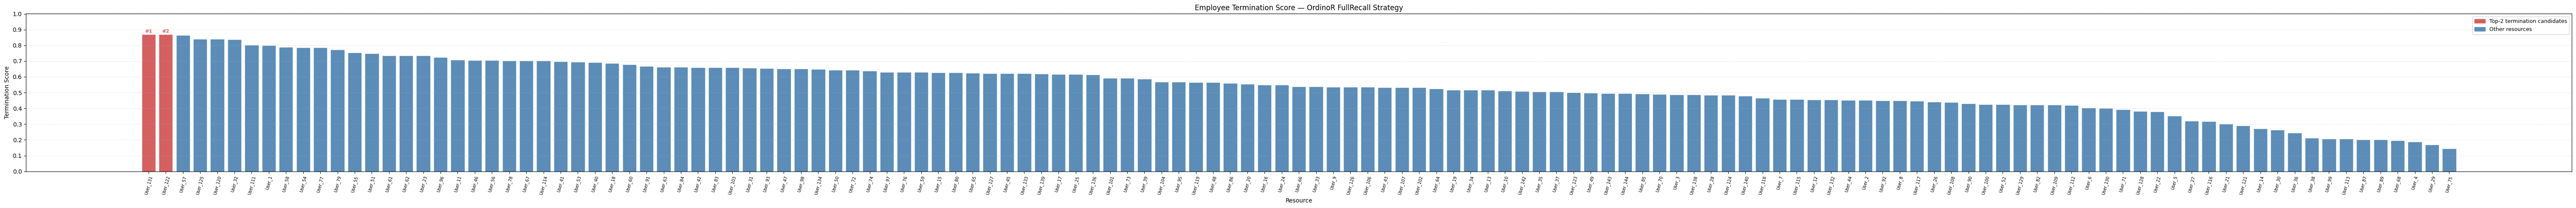

In [52]:
top2_resources = set(termination_candidates["resource"])

colors = [
    "#d65f5f" if r in top2_resources else "#5b8db8"
    for r in resource_metrics["resource"]
]

fig, ax = plt.subplots(figsize=(max(10, len(resource_metrics) * 0.45), 5))

bars = ax.bar(
    resource_metrics["resource"],
    resource_metrics["termination_score"],
    color=colors,
    edgecolor="white",
    linewidth=0.4,
)

# Annotate the top-2 bars
for bar, row in zip(bars, resource_metrics.itertuples()):
    if row.resource in top2_resources:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"#{row.rank}",
            ha="center", va="bottom", fontsize=8, fontweight="bold", color="#d65f5f",
        )

# Legend patches
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color="#d65f5f", label="Top-2 termination candidates"),
    mpatches.Patch(color="#5b8db8", label="Other resources"),
]
ax.legend(handles=legend_handles, fontsize=9)

ax.set_xlabel("Resource")
ax.set_ylabel("Termination Score")
ax.set_title("Employee Termination Score — OrdinoR FullRecall Strategy")
ax.set_ylim(0, min(1.05, resource_metrics["termination_score"].max() * 1.15))
ax.tick_params(axis="x", rotation=75, labelsize=7)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.1))
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()